<a href="https://colab.research.google.com/github/nikch97/pytorch/blob/main/neuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
#create a Model class inheriting nn.Module
class Model(nn.Module):
  def __init__(self, input_fe=4, h1=8, h2=9, output_fe=3):
    super().__init__() #instantiate our nn.Module
    self.fc1=nn.Linear(input_fe, h1)
    self.fc2=nn.Linear(h1, h2)
    self.out=nn.Linear(h2, output_fe)

  #move forward function (activation func)
  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x


In [ ]:
#pick a manual seed for randomization
torch.manual_seed(41)
#create an instance of model
model= Model()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [ ]:
my_df['species'] = my_df['species'].replace({'setosa':0, 'versicolor':1, 'virginica':2})

/tmp/ipykernel_10179/304997039.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace({'setosa':0, 'versicolor':1, 'virginica':2})


In [ ]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
#train, test, split, set x, y
x = my_df.drop('species', axis=1).values
y = my_df['species'].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=41)

In [ ]:
#convert x features to float tensors
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)

In [ ]:
#convert y labels to tensors long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [ ]:
# set the criterion of model to measure the error
criterion = nn.CrossEntropyLoss()
#choose Adam optimizer, lr= learnin rate(if error desnt go down after a bunch of iterations(epochs), lower lr)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
#train our model
epochs=100
losses =[]
for i in range(epochs):
  #make a prediction
  y_pred = model.forward(x_train)
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())

  #print every 10 epoch
  if i % 10 == 0:
    print(f'epoch: {i} loss: {loss}')
  #back propagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

epoch: 0 loss: 1.1251550912857056
epoch: 10 loss: 1.0096259117126465
epoch: 20 loss: 0.8157405853271484
epoch: 30 loss: 0.585706353187561
epoch: 40 loss: 0.3999636471271515
epoch: 50 loss: 0.26768800616264343
epoch: 60 loss: 0.17942364513874054
epoch: 70 loss: 0.12151692062616348
epoch: 80 loss: 0.0860118493437767
epoch: 90 loss: 0.06520849466323853


Text(0.5, 0, 'epoch')

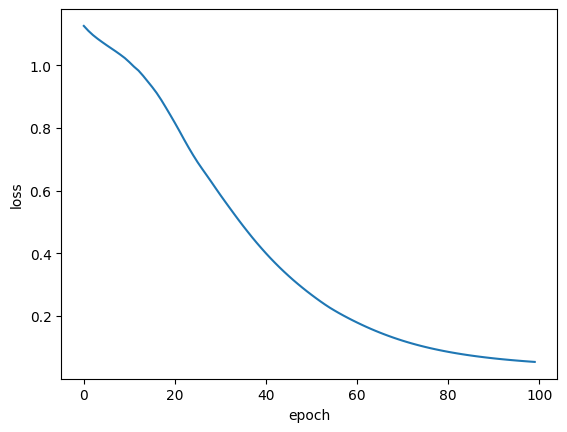

In [ ]:
#graph it out
plt.plot(range(epochs), losses)
plt.ylabel('loss')
plt.xlabel('epoch')

In [ ]:
#evaluate model on test data set
with torch.no_grad(): #tutn off back propagation
  y_eval = model.forward(x_test)# x_test are features from test set, y_eval is prediction
  loss = criterion(y_eval, y_test) #find the loss or error

In [ ]:
loss

tensor(0.1315)

In [ ]:
correct=0
with torch.no_grad():
  for i,data in enumerate(x_test):
    y_val = model.forward(data)
    #what type of flower the network think it is
    print(f'{i+1}. {str(y_val)} \t{y_test[i]}')

    if y_val.argmax().item()== y_test[i]:
      correct +=1
print(f'the {correct} answers')


1. tensor([-5.8760,  4.4628,  6.5124]) 	2
2. tensor([-7.5436,  4.1670,  9.7255]) 	2
3. tensor([-8.4504,  5.1271, 10.1987]) 	2
4. tensor([-4.3398,  5.6267,  2.5608]) 	1
5. tensor([-7.1825,  4.8754,  8.2992]) 	2
6. tensor([-3.3974,  5.3463,  1.2803]) 	1
7. tensor([-5.9231,  4.9822,  5.9997]) 	2
8. tensor([-4.2881,  5.7003,  2.3889]) 	1
9. tensor([-6.5356,  4.9257,  7.1260]) 	2
10. tensor([-8.0509,  4.4129, 10.3286]) 	2
11. tensor([-5.6762,  4.9500,  5.6215]) 	2
12. tensor([ 4.5662, -2.2476, -2.8911]) 	0
13. tensor([ 4.2571, -1.9967, -2.7330]) 	0
14. tensor([-2.1108,  4.0515,  0.5799]) 	1
15. tensor([ 3.4575, -1.2098, -2.3514]) 	0
16. tensor([-5.4724,  5.1165,  5.0934]) 	2
17. tensor([ 4.0557, -1.7949, -2.6492]) 	0
18. tensor([-5.8075,  4.6053,  6.2458]) 	1
19. tensor([ 4.4343, -2.1392, -2.8242]) 	0
20. tensor([ 3.4527, -1.2514, -2.3660]) 	0
21. tensor([-2.6189,  4.5619,  0.8574]) 	1
22. tensor([-7.7412,  4.7377,  9.4199]) 	2
23. tensor([ 3.5744, -1.3221, -2.4135]) 	0
24. tensor([ 4.5365,

In [ ]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])

In [ ]:
with torch.no_grad():
  print(model(new_iris))


tensor([ 4.5365, -2.2383, -2.8684])


In [ ]:
#save our NN model
torch.save(model.state_dict(), 'iris_model.pt')

In [ ]:
#load the saved model
new_model = Model()
new_model.load_state_dict(torch.load('iris_model.pt'))

<All keys matched successfully>

In [ ]:
#make sure loaded correctly
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)